# 01 — Exploration et Prétraitement — Fashion-MNIST
**Projet : Optimisation Multi-Objectifs pour AutoML — Option 2**

Objectif : charger Fashion-MNIST, normaliser, aplatir en vecteurs 784-D, créer les splits train/val/test et sauvegarder les fichiers `.npy` utilisés par les notebooks suivants.

In [1]:
import os
# Forcer le répertoire de travail = dossier du notebook
notebook_dir = os.path.dirname(os.path.abspath(__file__)) if "__file__" in dir() else os.getcwd()
# Compatible VS Code, Jupyter, Google Colab
try:
    import IPython
    _nb_path = IPython.extract_module_locals()[1].get("__vsc_ipynb_file__") or                IPython.extract_module_locals()[1].get("__session__", "")
    if _nb_path and os.path.exists(os.path.dirname(_nb_path)):
        os.chdir(os.path.dirname(_nb_path))
except Exception:
    pass
print(f"Répertoire de travail : {os.getcwd()}")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from sklearn.model_selection import train_test_split

print("Librairies chargées.")
CLASS_NAMES = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

Répertoire de travail : c:\Users\HP\Downloads\automl_fashion_mnist_option2_FINAL (2)\automl_final
Librairies chargées.


## 1. Chargement de Fashion-MNIST
Fashion-MNIST : 70 000 images 28×28 pixels, 10 classes de vêtements.

In [2]:
# Chargement via Keras (si disponible) sinon depuis les .npy déjà préparés
try:
    from tensorflow.keras.datasets import fashion_mnist
    (X_raw_train, y_raw_train), (X_raw_test, y_raw_test) = fashion_mnist.load_data()
    print(f"Chargé via Keras — train: {X_raw_train.shape}, test: {X_raw_test.shape}")
    LOADED_FROM_KERAS = True
except Exception:
    LOADED_FROM_KERAS = False
    print("Keras non dispo — chargement depuis les .npy préparés.")

Keras non dispo — chargement depuis les .npy préparés.


## 2. Normalisation et Aplatissement
Pixels [0,255] → [0.0,1.0] | Images (28,28) → vecteurs (784,)

In [3]:
if LOADED_FROM_KERAS:
    # Normalisation
    X_all_flat = (X_raw_train.astype("float32") / 255.0).reshape(-1, 784)
    X_test_flat = (X_raw_test.astype("float32") / 255.0).reshape(-1, 784)
    y_all = y_raw_train.astype(np.uint8)
    y_test_flat = y_raw_test.astype(np.uint8)

    # Split stratifié 80/20 → train (48000) / val (12000)
    X_train_flat, X_val_flat, y_train_flat, y_val_flat = train_test_split(
        X_all_flat, y_all, test_size=0.2, random_state=42, stratify=y_all
    )
    print(f"X_train_flat : {X_train_flat.shape}")
    print(f"X_val_flat   : {X_val_flat.shape}")
    print(f"X_test_flat  : {X_test_flat.shape}")
else:
    # Charger depuis les .npy déjà préparés
    X_train_flat = np.load("data_prepared/X_train_flat.npy")
    X_val_flat   = np.load("data_prepared/X_val_flat.npy")
    X_test_flat  = np.load("data_prepared/X_test_flat.npy")
    y_train_flat = np.load("data_prepared/y_train_flat.npy")
    y_val_flat   = np.load("data_prepared/y_val_flat.npy")
    y_test_flat  = np.load("data_prepared/y_test_flat.npy")
    print("Données chargées depuis data_prepared/")
    print(f"X_train_flat : {X_train_flat.shape}")
    print(f"X_val_flat   : {X_val_flat.shape}")
    print(f"X_test_flat  : {X_test_flat.shape}")

print(f"\nPixels : min={X_train_flat.min():.3f}  max={X_train_flat.max():.3f}")
print(f"Classes : {np.unique(y_train_flat)}")

Données chargées depuis data_prepared/
X_train_flat : (48000, 784)
X_val_flat   : (12000, 784)
X_test_flat  : (10000, 784)

Pixels : min=0.000  max=1.000
Classes : [0 1 2 3 4 5 6 7 8 9]


## 3. Visualisation des images

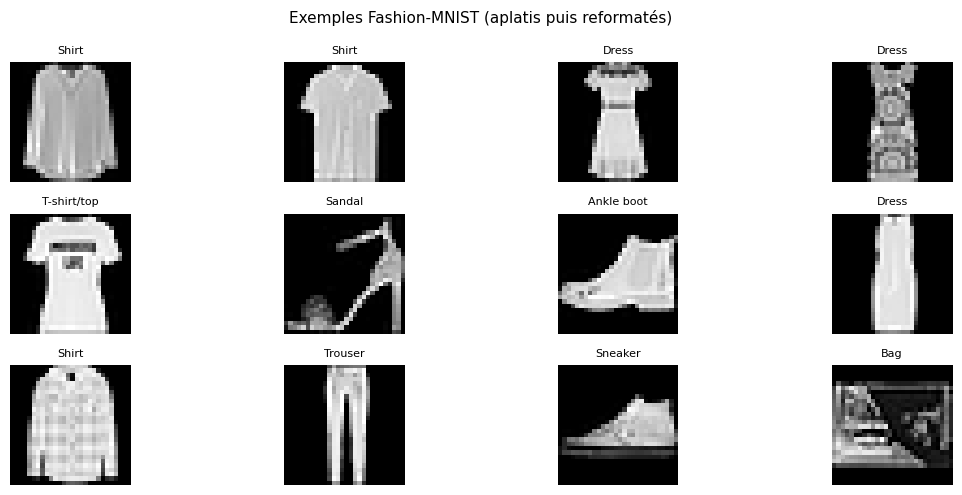

In [4]:
plt.figure(figsize=(12, 5))
for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(X_train_flat[i].reshape(28, 28), cmap="gray")
    plt.title(CLASS_NAMES[y_train_flat[i]], fontsize=8)
    plt.axis("off")
plt.suptitle("Exemples Fashion-MNIST (aplatis puis reformatés)", fontsize=11)
plt.tight_layout()
plt.savefig("results/sample_images.png", dpi=100, bbox_inches="tight")
plt.show()
os.makedirs("results", exist_ok=True)

## 4. Distribution des classes

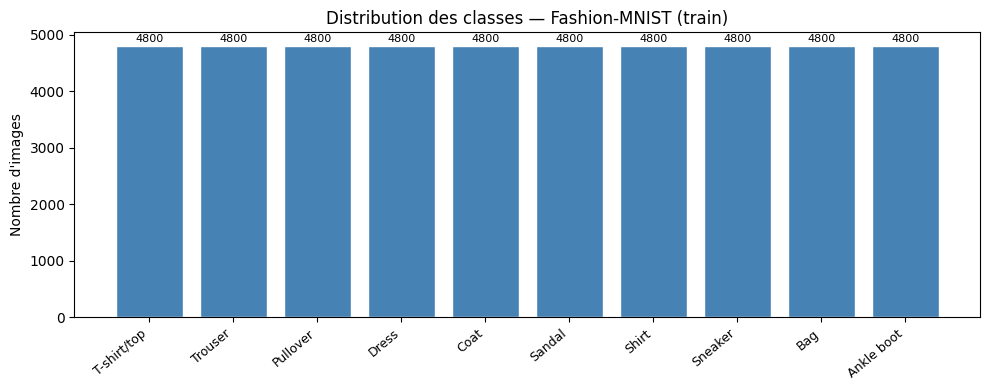

Classes parfaitement équilibrées : [4800 4800 4800 4800 4800 4800 4800 4800 4800 4800]


In [5]:
counts = np.bincount(y_train_flat)
plt.figure(figsize=(10, 4))
bars = plt.bar(CLASS_NAMES, counts, color="steelblue", edgecolor="white")
plt.xticks(rotation=40, ha="right", fontsize=9)
plt.title("Distribution des classes — Fashion-MNIST (train)")
plt.ylabel("Nombre d'images")
for bar, c in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
             str(c), ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.savefig("results/class_distribution.png", dpi=100, bbox_inches="tight")
plt.show()
print("Classes parfaitement équilibrées :", counts)

## 5. Sous-ensemble pour l'optimisation (10 000 images)
SVM, k-NN et GB sont trop lents sur 48 000 images — on utilise un sous-ensemble stratifié.

In [6]:
rng = np.random.RandomState(42)
idx_optim = rng.choice(len(X_train_flat), 10000, replace=False)
X_train_optim = X_train_flat[idx_optim]
y_train_optim = y_train_flat[idx_optim]

print(f"Sous-ensemble : {X_train_optim.shape}")
print("Distribution:", np.bincount(y_train_optim))

Sous-ensemble : (10000, 784)
Distribution: [1007 1036  982  987 1001  986 1035  977 1021  968]


## 6. Sauvegarde des données préparées

In [7]:
os.makedirs("data_prepared", exist_ok=True)
os.makedirs("results", exist_ok=True)

np.save("data_prepared/X_train_flat.npy",  X_train_flat)
np.save("data_prepared/X_val_flat.npy",    X_val_flat)
np.save("data_prepared/X_test_flat.npy",   X_test_flat)
np.save("data_prepared/y_train_flat.npy",  y_train_flat)
np.save("data_prepared/y_val_flat.npy",    y_val_flat)
np.save("data_prepared/y_test_flat.npy",   y_test_flat)
np.save("data_prepared/X_train_optim.npy", X_train_optim)
np.save("data_prepared/y_train_optim.npy", y_train_optim)

print("Fichiers sauvegardés :")
for f in sorted(os.listdir("data_prepared")):
    arr = np.load(f"data_prepared/{f}")
    print(f"  {f:35s} shape={arr.shape}  dtype={arr.dtype}")

Fichiers sauvegardés :
  X_test_cnn.npy                      shape=(10000, 28, 28, 1)  dtype=float32
  X_test_flat.npy                     shape=(10000, 784)  dtype=float32
  X_train_final.npy                   shape=(48000, 28, 28, 1)  dtype=float32
  X_train_flat.npy                    shape=(48000, 784)  dtype=float32
  X_train_optim.npy                   shape=(10000, 784)  dtype=float32
  X_val.npy                           shape=(12000, 28, 28, 1)  dtype=float32
  X_val_flat.npy                      shape=(12000, 784)  dtype=float32
  y_test.npy                          shape=(10000,)  dtype=uint8
  y_test_cat.npy                      shape=(10000, 10)  dtype=float64
  y_test_flat.npy                     shape=(10000,)  dtype=uint8
  y_train_final.npy                   shape=(48000, 10)  dtype=float64
  y_train_flat.npy                    shape=(48000,)  dtype=uint8
  y_train_optim.npy                   shape=(10000,)  dtype=uint8
  y_val.npy                           shape=(1200

## 7. Récapitulatif — Espace de recherche (Option 2)

| Modèle | Hyperparamètres optimisés | Objectifs |
|---|---|---|
| **Random Forest** | n_estimators, max_depth, min_samples_split, max_features | Accuracy ↑, Temps inférence ↓ |
| **SVM** | C, kernel, gamma | Accuracy ↑, Temps entraînement ↓ |
| **k-NN** | n_neighbors, weights, metric | Accuracy ↑, Temps prédiction ↓ |
| **Gradient Boosting** | n_estimators, learning_rate, max_depth | Accuracy ↑, Temps inférence ↓ |